**Brief Information About the Warm Up:**

- The evaluation metric used is MAPE (Mean Absolute Percentage Error).
- The agri-food sector includes the production, processing and distribution of food which requires significant natural resources, energy and emissions, contributing significantly to global warming. Therefore, the goal is to **predict global warming based on the factors related to agri-food sector.**

In [1]:
# Import library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Setup pandas
pd.set_option('display.max_columns', None)

In [2]:
# Get the current working directory
os.getcwd()

'/Users/ahmadyusufalbadri/Documents/1 - Learning/4 - Competition/datavidia 2025/Datavidia'

# Initial Data Checking

In [3]:
# Import train data
df_train = pd.read_csv('data/train.csv')
df_train.sample(5)

,Unnamed: 0,Negara/Tahun,Emisi Savanna Api,Emisi Kebakaran Hutan,Emisi Residu Tanaman,Emisi Budidaya Padi,Emisi Tanah Organik Yang Dikeringkan (Co2),Emisi Pembuatan Pestisida,Emisi Transportasi Makanan,Lahan Hutan,Konversi Hutan Bersih,Emisi Konsumsi Rumah Tangga Makanan,Emisi Ritel Makanan,Emisi Penggunaan Listrik Di Pertanian,Emisi Kemasan Makanan,Emisi Sistem Agrifood Pembuangan Limbah,Emisi Pengolahan Makanan,Emisi Manufaktur Pupuk,Emisi IPPU,Emisi Kotoran Diterapkan Pada Tanah,Emisi Pupuk Kandang Di Padang Rumput,Emisi Manajemen Pupuk,Emisi Kebakaran Di Tanah Organik,Emisi Kebakaran Di Hutan Tropis Yang Lembab,Penggunaan Energi Di Pertanian,Populasi Pedesaan,Populasi Perkotaan,Total Populasi - Pria,Total Populasi - Wanita,Emisi Total,Peningkatan Suhu Rata - Rata ° C
3359,3359,Mongolia/2011,891.0175,38.3699,35.1969,319.680801,22559.8439,6.000000,205.727700,0.0000,153.9919,443.8505,435.9204,42.755700,332.005034,2505.5094,1233.812506,398.705622,250.2715,514.4882,3245.072100,832.1395,0.0,0.0000,23.1978,884714.0,1876802.0,1366548.0,1377389.0,34467.556864,0.624083
4091,4091,Puerto Rico/1991,0.0683,0.2661,0.0302,0.000000,134.2189,133.616818,1841.653064,-1247.6938,0.0000,904.2383,1008.6903,28.519600,108.348674,994.6923,320.834899,10753.102392,NaN,52.9869,255.624600,55.9322,0.0,0.2661,NaN,244850.0,3306737.0,1732097.0,1846353.0,15345.395847,0.359833
2271,2271,Haiti/2003,0.0668,0.0000,34.1392,170.284800,0.0000,0.000000,88.857900,-137.8356,207.2246,49.2076,1152.3336,23.948334,67.631366,2651.7167,220.213857,363.146066,144.0262,133.9400,907.074000,195.1913,0.0,0.0000,38.9864,5328009.0,3648543.0,4376534.0,4435711.0,6310.153122,1.181167
2883,2883,Liberia/1996,0.1979,48.5373,11.5862,24.893600,93.2973,12.232871,13.654800,-377.9245,13660.1480,NaN,0.1917,506.028170,212.033652,79.9711,294.067022,599.422429,19.0134,12.8092,61.622500,23.4690,0.0,48.5373,3.1710,1249761.0,941418.0,1084387.0,1119580.0,15346.959944,0.609833
3889,3889,Palau/2014,0.0000,0.0000,NaN,1639.724833,0.0000,11.481085,12.920300,NaN,NaN,2.0101,4.1750,1.560400,74.018133,0.6306,483.126100,2791.684228,1.1087,NaN,6250.660317,NaN,0.0,0.0000,11.5299,4743.0,16351.0,9443.0,8353.0,11284.629694,0.959182


In [4]:
# Import test data
df_test = pd.read_csv('data/test.csv')
df_test.sample(5)

,Unnamed: 0,Negara/Tahun,Emisi Savanna Api,Emisi Kebakaran Hutan,Emisi Residu Tanaman,Emisi Budidaya Padi,Emisi Tanah Organik Yang Dikeringkan (Co2),Emisi Pembuatan Pestisida,Emisi Transportasi Makanan,Lahan Hutan,Konversi Hutan Bersih,Emisi Konsumsi Rumah Tangga Makanan,Emisi Ritel Makanan,Emisi Penggunaan Listrik Di Pertanian,Emisi Kemasan Makanan,Emisi Sistem Agrifood Pembuangan Limbah,Emisi Pengolahan Makanan,Emisi Manufaktur Pupuk,Emisi IPPU,Emisi Kotoran Diterapkan Pada Tanah,Emisi Pupuk Kandang Di Padang Rumput,Emisi Manajemen Pupuk,Emisi Kebakaran Di Tanah Organik,Emisi Kebakaran Di Hutan Tropis Yang Lembab,Penggunaan Energi Di Pertanian,Populasi Pedesaan,Populasi Perkotaan,Total Populasi - Pria,Total Populasi - Wanita,Emisi Total
370,370,Dominican Republic/2019,2.8827,5.3026,59.8619,1373.195300,0.0000,207.000000,850.7194,-2161.0050,603.68,1313.5917,1718.0554,714.572600,256.16340,4269.0163,1534.297100,363.146066,2230.0321,404.9664,1577.8698,361.7951,0.0,1.8067,332.9299,1998330.0,8998444.0,5472410.0,5409472.0,16019.879466
0,0,Afghanistan/2015,0.8454,0.0000,403.3181,642.880000,0.0000,81.852555,440.0315,-246.2191,0.00,1570.3394,370.6039,75.161400,353.93064,3090.5068,1645.129815,27.235400,256.7030,423.5038,2719.1528,797.9007,0.0,0.0000,NaN,25368923.0,8367571.0,17071446.0,16682054.0,12652.876111
506,506,Grenada/2017,0.0000,0.0000,0.0303,448.164725,0.0000,11.481085,11.1454,0.0000,0.00,15.8129,20.2818,17.004663,98.42874,32.9811,209.587728,658.540604,3.9767,0.8284,3.9467,0.9264,0.0,0.0000,0.0415,68831.0,38994.0,60681.0,60239.0,1533.178744
641,641,Jordan/2020,0.2109,0.0000,7.8891,246.407276,0.0000,14.000000,778.4384,0.0000,0.00,1171.5635,517.9974,1200.423200,10.62300,2072.3285,4.004700,1153.622700,2849.7167,19.7443,394.1619,43.4223,0.0,0.0000,313.0803,876059.0,9332603.0,5670775.0,5257947.0,10797.634176
1179,1179,Sweden/2018,5.6417,9.0590,205.4916,653.496807,9491.3842,26.000000,1482.5360,-44979.5867,23845.36,75.3251,459.8932,16.303000,383.82500,888.0167,662.508500,943.417794,9872.7624,381.4990,318.8342,923.0311,0.0,0.0000,1346.1066,1254718.0,8727991.0,5105006.0,5057292.0,7010.905202


In [5]:
# Check on sample submission data
sample_submission = pd.read_csv('data/sample_submission.csv')
sample_submission.head()

,id,Peningkatan Suhu Rata - Rata ° C
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


In [6]:
# Check the dimension of test and sample submission
print(sample_submission.shape)
print(df_test.shape)

(1362, 2)
(1362, 30)


In [7]:
# Check train and test data on country and year availability

# First, add the negara and tahun column
df_test[['Negara', 'Tahun']] = df_test['Negara/Tahun'].str.split('/', expand=True)
df_test = df_test.iloc[:, 2:]
df_train[['Negara', 'Tahun']] = df_train['Negara/Tahun'].str.split('/', expand=True)
df_train = df_train.iloc[:, 2:]

In [8]:
# Sampling year availability of country in the train and test data
def sample_data_check(data_train, data_test, country_name):
    train = data_train[data_train['Negara'] == country_name]['Tahun'].unique()
    test = data_test[data_test['Negara'] == country_name]['Tahun'].unique()
    print(f'Sample on {country_name}: \n')
    print(f'Training data has {len(train)} years of data as follow:')
    print(train)
    print(f'\nTest data has {len(test)} years of data as follow:')
    print(test)

In [9]:
# Sampling on Turkmenistan
sample_data_check(df_train, df_test, 'Turkmenistan')

Sample on Turkmenistan: 

Training data has 23 years of data as follow:
['1992' '1993' '1994' '1995' '1996' '1997' '1998' '1999' '2000' '2001'
 '2002' '2003' '2004' '2005' '2006' '2007' '2008' '2009' '2010' '2011'
 '2012' '2013' '2014']

Test data has 6 years of data as follow:
['2015' '2016' '2017' '2018' '2019' '2020']


In [10]:
# Sampling on Indonesia
sample_data_check(df_train, df_test, 'Indonesia')

Sample on Indonesia: 

Training data has 25 years of data as follow:
['1990' '1991' '1992' '1993' '1994' '1995' '1996' '1997' '1998' '1999'
 '2000' '2001' '2002' '2003' '2004' '2005' '2006' '2007' '2008' '2009'
 '2010' '2011' '2012' '2013' '2014']

Test data has 6 years of data as follow:
['2015' '2016' '2017' '2018' '2019' '2020']


In [11]:
# Count the number of countries
print(df_test['Negara'].nunique(dropna=False))
print(df_train['Negara'].nunique(dropna=False))

227
236


In [12]:
# Check total country
temp = np.append(df_test['Negara'].unique(), df_train['Negara'].unique())
unique_element = np.unique(temp)
print(len(unique_element))

236


In [13]:
# Check years availability
def year_check(data):
    temp = data.groupby('Negara')['Tahun'].nunique(dropna=False).reset_index()
    temp = temp.groupby('Tahun')['Negara'].nunique()
    
    # Create a bar chart
    temp.plot.bar()
    
    # Add labels on top of bars
    for i, v in enumerate(temp.values):
        plt.text(i, v + 5, str(v), ha='center', fontsize=12)
    
    # Set y-axis limit (max height)
    plt.ylim(0, max(temp) + 25)
    
    # Title and labels
    plt.xlabel("# Years Available")
    plt.ylabel("# Countries")
    
    plt.show()

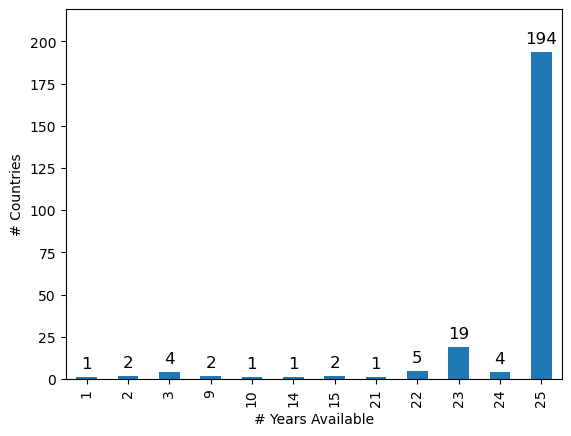

In [14]:
# Check on training data
year_check(df_train)

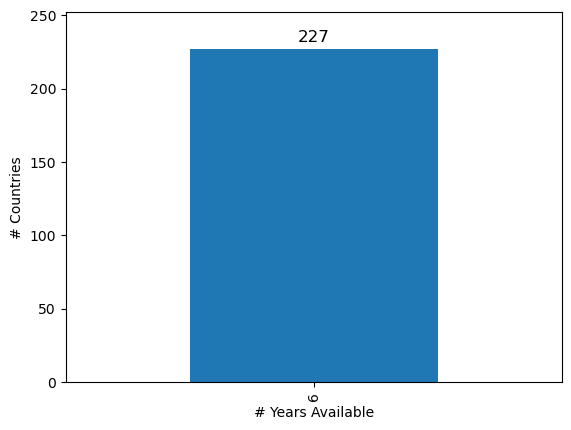

In [15]:
# Check on testing data
year_check(df_test)

In [16]:
# Check country with only 15 years of available data in train data
temp = df_train.groupby('Negara')['Tahun'].nunique(dropna=False).reset_index()
temp[temp['Tahun'] == 15]

,Negara,Tahun
19,Belgium,15
123,Luxembourg,15


In [17]:
# Check sample of belgium
sample_data_check(df_train, df_test, 'Belgium')

Sample on Belgium: 

Training data has 15 years of data as follow:
['2000' '2001' '2002' '2003' '2004' '2005' '2006' '2007' '2008' '2009'
 '2010' '2011' '2012' '2013' '2014']

Test data has 6 years of data as follow:
['2015' '2016' '2017' '2018' '2019' '2020']


In [18]:
# Check sample of Luxembourg
sample_data_check(df_train, df_test, 'Luxembourg')

Sample on Luxembourg: 

Training data has 15 years of data as follow:
['2000' '2001' '2002' '2003' '2004' '2005' '2006' '2007' '2008' '2009'
 '2010' '2011' '2012' '2013' '2014']

Test data has 6 years of data as follow:
['2015' '2016' '2017' '2018' '2019' '2020']


In [19]:
# Check training data
temp = df_train.groupby('Negara')['Tahun'].agg(['nunique', 'min', 'max']).reset_index()
temp2 = df_test.groupby('Negara')['Tahun'].agg(['nunique', 'min', 'max']).reset_index()
temp = temp.merge(temp2, how='left', on='Negara') # suffix x and y for train and test data respectively
temp

,Negara,nunique_x,min_x,max_x,nunique_y,min_y,max_y
0,Afghanistan,25,1990,2014,6.0,2015,2020
1,Albania,25,1990,2014,6.0,2015,2020
2,Algeria,25,1990,2014,6.0,2015,2020
3,American Samoa,25,1990,2014,6.0,2015,2020
4,Andorra,25,1990,2014,6.0,2015,2020
...,...,...,...,...,...,...,...
231,Western Sahara,25,1990,2014,6.0,2015,2020
232,Yemen,25,1990,2014,6.0,2015,2020
233,Yugoslav SFR,2,1990,1991,NaN,NaN,NaN
234,Zambia,25,1990,2014,6.0,2015,2020


In [20]:
# Check test data period
temp.min_y.unique(), temp.max_y.unique()

(array(['2015', nan], dtype=object), array(['2020', nan], dtype=object))

In [21]:
# Check test data period
temp.groupby(['min_x', 'max_x'])['Negara'].nunique()

min_x  max_x
1990   1990       1
       1991       2
       1992       2
       1999       1
       2010       1
       2011       1
       2014     194
1991   2014       4
1992   2005       1
       2014      19
1993   2014       4
2000   2014       2
2006   2014       2
2012   2014       2
Name: Negara, dtype: int64

In [22]:
temp.groupby('max_x')['nunique_y'].count()

max_x
1990      0
1991      0
1992      0
1999      0
2005      0
2010      0
2011      0
2014    227
Name: nunique_y, dtype: int64

From quick check of the data, we know that:
1. We don't have any information about the global warming in the test data which will be used for submission to kaggle.
2. The submission format is simple, we just need to save the prediction of the global warming in celcius for all of the 1,362 rows.
3. There are 236 countries in the total of train (236) and test data (227) which shows that some countries in the train data are not available in the test data.
5. Looking at a sample of Turkmenistan, it seems that the splitting of train and test data use panel data logic for upcoming year, which use the next year period for testing.
6. Test data only available for countries that has a period until 2014 in training data (which is 227 countries), because in the test data we need to "forecast" or predict the global warming for these countries from 2015 until 2020.

# EDA

Goals of this EDA is to find variables that shows clear relation with global warming.

In [27]:
from geopy.geocoders import Nominatim

# Get the latitude and longitude of the country
def lat_lon(list_countries, agent):
    # Instantiate a new Nominatim client
    app = Nominatim(user_agent="data_puler")
    
    lat_lon_data = {'country': [], 'lat': [], 'lon': []}
    for i in list_countries:
        try:
            location = app.geocode(i).raw
            lat_lon_data['country'].append(i)
            lat_lon_data['lat'].append(float(location['lat']))
            lat_lon_data['lon'].append(float(location['lon']))
        except:
            lat_lon_data['country'].append(i)
            lat_lon_data['lat'].append(-99999)
            lat_lon_data['lon'].append(-99999)

    return lat_lon_data

In [28]:
# Test on Indonesia and Malaysia
lat_lon_country = lat_lon(['Indonesia', 'Malaysia'], 'data_puller')
lat_lon_country

{'country': ['Indonesia', 'Malaysia'],
 'lat': [-2.4833826, 4.5693754],
 'lon': [117.8902853, 102.2656823]}

In [30]:
# Execute on getting the latitude and longitude data of each country
lat_lon_country = lat_lon(df_train['Negara'].unique(), 'data_puller') # Will request for 236 countries

In [52]:
# Check country with -99999
print(len(np.array(lat_lon_country['country'])[np.where(np.array(lat_lon_country['lat']) == -99999)[0]]))
print(len(np.array(lat_lon_country['country'])[np.where(np.array(lat_lon_country['lon']) == -99999)[0]]))

15
15


In [48]:
# Save current lat_lon_country data
df_lat_lon_country = pd.DataFrame(lat_lon_country)
df_lat_lon_country.to_csv('lat_lon_data_pul1.csv')

In [67]:
# Retry for lat_lon_country
lat_lon_country = lat_lon(df_lat_lon_country[df_lat_lon_country['lat'] == -99999]['country'].unique(), 'data_puller')
pd.DataFrame(lat_lon_country)

,country,lat,lon
0,"China, Macao SAR",-99999.000000,-99999.000000
1,"China, Taiwan Province of",-99999.000000,-99999.000000
2,Ethiopia PDR,-99999.000000,-99999.000000
3,Indonesia,-2.483383,117.890285
4,Iran (Islamic Republic of),32.647531,54.564352
5,Iraq,33.095579,44.174977
6,Ireland,52.865196,-7.979460
7,Isle of Man,54.193680,-4.559115
8,Israel,31.394800,34.633583
9,Italy,42.638426,12.674297


In [69]:
# Individual sample
lat_lon(['Pacific Island'], 'data_puller')

{'country': ['Pacific Island'], 'lat': [45.0015763], 'lon': [-1.1998453]}

In [71]:
# Make temporary data
temp = pd.DataFrame(lat_lon_country)
temp['country_adj'] = [
    'Macao',
    'Taiwan',
    'Ethiopia',
    'Indonesia',
    'Iran',
    'Iraq',
    'Ireland',
    'Isle of Man',
    'Israel',
    'Italy',
    'Jamaica',
    'Netherlands Antilles',
    'Pacific Island',
    'Saint Helena',
    'Yugoslav'
]
temp[['lat_adj', 'lon_adj']] = pd.DataFrame(lat_lon(temp['country_adj'], 'data_puller'))[['lat', 'lon']]
temp

,country,lat,lon,country_adj,lat_adj,lon_adj
0,"China, Macao SAR",-99999.000000,-99999.000000,Macao,22.175760,113.551414
1,"China, Taiwan Province of",-99999.000000,-99999.000000,Taiwan,23.598323,120.835377
2,Ethiopia PDR,-99999.000000,-99999.000000,Ethiopia,10.211670,38.652120
3,Indonesia,-2.483383,117.890285,Indonesia,-2.483383,117.890285
4,Iran (Islamic Republic of),32.647531,54.564352,Iran,32.647531,54.564352
5,Iraq,33.095579,44.174977,Iraq,33.095579,44.174977
6,Ireland,52.865196,-7.979460,Ireland,52.865196,-7.979460
7,Isle of Man,54.193680,-4.559115,Isle of Man,54.193680,-4.559115
8,Israel,31.394800,34.633583,Israel,31.394800,34.633583
9,Italy,42.638426,12.674297,Italy,42.638426,12.674297


In [80]:
# Replace -99999 values
df_lat_lon_country.iloc[df_lat_lon_country[df_lat_lon_country['country'].isin(temp['country'])][['lat', 'lon']].index, 1:] = temp[['lat_adj', 'lon_adj']]
df_lat_lon_country[df_lat_lon_country['country'].isin(temp['country'])]

,country,lat,lon
45,"China, Macao SAR",22.175760,113.551414
47,"China, Taiwan Province of",23.598323,120.835377
72,Ethiopia PDR,10.211670,38.652120
100,Indonesia,-2.483383,117.890285
101,Iran (Islamic Republic of),32.647531,54.564352
102,Iraq,33.095579,44.174977
103,Ireland,52.865196,-7.979460
104,Isle of Man,54.193680,-4.559115
105,Israel,31.394800,34.633583
106,Italy,42.638426,12.674297


In [81]:
# Save lat and lon csv
df_lat_lon_country.to_csv('lat_lon_data_pul2.csv')

In [84]:
# Input lat lon data to train data
df_train = df_train.merge(df_lat_lon_country, how='left', left_on='Negara', right_on='country')
df_train

,Emisi Savanna Api,Emisi Kebakaran Hutan,Emisi Residu Tanaman,Emisi Budidaya Padi,Emisi Tanah Organik Yang Dikeringkan (Co2),Emisi Pembuatan Pestisida,Emisi Transportasi Makanan,Lahan Hutan,Konversi Hutan Bersih,Emisi Konsumsi Rumah Tangga Makanan,Emisi Ritel Makanan,Emisi Penggunaan Listrik Di Pertanian,Emisi Kemasan Makanan,Emisi Sistem Agrifood Pembuangan Limbah,Emisi Pengolahan Makanan,Emisi Manufaktur Pupuk,Emisi IPPU,Emisi Kotoran Diterapkan Pada Tanah,Emisi Pupuk Kandang Di Padang Rumput,Emisi Manajemen Pupuk,Emisi Kebakaran Di Tanah Organik,Emisi Kebakaran Di Hutan Tropis Yang Lembab,Penggunaan Energi Di Pertanian,Populasi Pedesaan,Populasi Perkotaan,Total Populasi - Pria,Total Populasi - Wanita,Emisi Total,Peningkatan Suhu Rata - Rata ° C,Negara,Tahun,country,lat,lon
0,14.7237,0.0557,205.6077,686.0000,0.0,11.807483,63.1152,-2388.8030,0.0000,79.0851,109.6446,14.2666,67.631366,691.7888,252.21419,11.997000,209.9778,260.1431,1590.5319,319.1763,0.0,0.0,NaN,9655167.0,2593947.0,5348387.0,5346409.0,2198.963539,0.536167,Afghanistan,1990,Afghanistan,33.768006,66.238514
1,14.7237,0.0557,209.4971,678.1600,0.0,11.712073,61.2125,-2388.8030,0.0000,80.4885,116.6789,11.4182,67.631366,710.8212,252.21419,12.853900,217.0388,268.6292,1657.2364,342.3079,0.0,0.0,NaN,10230490.0,2763167.0,5372959.0,5372208.0,2323.876629,0.020667,Afghanistan,1991,Afghanistan,33.768006,66.238514
2,14.7237,0.0557,196.5341,686.0000,0.0,11.712073,53.3170,-2388.8030,0.0000,80.7692,126.1721,9.2752,67.631366,743.6751,252.21419,13.492900,222.1156,264.7898,1653.5068,349.1224,0.0,0.0,NaN,10995568.0,2985663.0,6028494.0,6028939.0,2356.304229,-0.259583,Afghanistan,1992,Afghanistan,33.768006,66.238514
3,14.7237,0.0557,230.8175,686.0000,0.0,11.712073,54.3617,-2388.8030,0.0000,85.0678,81.4607,9.0635,67.631366,791.9246,252.21419,14.055900,201.2057,261.7221,1642.9623,352.2947,0.0,0.0,NaN,11858090.0,3237009.0,7003641.0,7000119.0,2368.470529,0.101917,Afghanistan,1993,Afghanistan,33.768006,66.238514
4,14.7237,0.0557,242.0494,705.6000,0.0,11.712073,53.9874,-2388.8030,0.0000,88.8058,90.4008,8.3962,67.631366,831.9181,252.21419,15.126900,182.2905,267.6219,1689.3593,367.6784,0.0,0.0,NaN,12690115.0,3482604.0,7733458.0,7722096.0,2500.768729,0.372250,Afghanistan,1994,Afghanistan,33.768006,66.238514
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5598,2795.6192,283.6316,109.3055,3.0243,0.0,87.000000,157.6366,262.6108,10677.6439,141.1969,340.6886,260.8153,28.342500,1004.2754,64.36670,1227.240253,709.7960,103.6080,2968.0562,302.3508,0.0,0.0,2074.1869,9410211.0,4676106.0,6034165.0,6805605.0,23601.395453,0.911917,Zimbabwe,2010,Zimbabwe,-18.455496,29.746841
5599,2918.2098,168.1659,100.7798,3.7456,0.0,94.000000,268.6740,648.0808,10670.8870,179.8443,328.7726,331.5380,26.920300,1019.7733,286.50940,1127.687805,843.8980,102.2926,3072.2327,312.2478,0.0,0.0,966.3719,9636932.0,4749717.0,6114111.0,6911674.0,23470.631605,0.191167,Zimbabwe,2011,Zimbabwe,-18.455496,29.746841
5600,2164.8953,259.4249,103.8422,5.5527,0.0,91.000000,304.6578,648.0808,10670.8870,170.8670,322.0831,317.3356,25.000800,1037.0116,280.77900,1127.687805,947.9330,102.4605,3101.1270,314.3433,0.0,0.0,908.2629,9880721.0,4830105.0,6223803.0,7041528.0,22903.232305,0.337000,Zimbabwe,2012,Zimbabwe,-18.455496,29.746841
5601,1544.9329,238.1898,96.8978,5.8016,0.0,73.000000,338.5506,648.0808,10670.8870,203.6878,335.2805,625.2430,22.669900,1045.1572,304.91080,1127.687805,869.9150,103.5893,3127.0658,317.9359,0.0,0.0,546.0138,10138667.0,4915839.0,6363142.0,7192279.0,22245.497305,0.089667,Zimbabwe,2013,Zimbabwe,-18.455496,29.746841
